# Propulsion Power Prediction

This notebook provides a complete workflow for training, evaluating, and testing propulsion power prediction models.

## Contents
1. Setup & Configuration
2. Data Loading & Exploration
3. Feature Engineering
4. Baseline Models
5. Neural Network Models
6. Uncertainty Quantification
7. Model Comparison
8. Distribution Shift Analysis
9. Making Predictions on New Data


## 1. Setup & Configuration


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Add models directory to path
sys.path.insert(0, 'models')
sys.path.insert(0, 'utils')

# Import our modules
from config import Config, default_config
from data_module import PropulsionDataModule
from baseline_models import create_baseline_model, MeanBaseline, LinearModel, RandomForestModel
from neural_models import create_mlp, NeuralNetworkTrainer, MLP, GaussianMLP
from uncertainty import DeepEnsemble, MCDropout, compute_uncertainty_metrics
from assessment import get_performance_metric

# PyTorch
import torch

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


PyTorch version: 2.6.0+cu124
Device: CUDA


In [2]:
# Configuration
config = Config()

# You can modify settings here
config.data.data_dir = "data/synthetic_data"  # or "data/real_data"
config.model.max_epochs = 100
config.model.batch_size = 256
config.model.n_ensemble_members = 5
config.model.early_stopping_patience = 10

# Create output directories
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.checkpoint_dir, exist_ok=True)

print("Configuration:")
print(f"  Data directory: {config.data.data_dir}")
print(f"  Max epochs: {config.model.max_epochs}")
print(f"  Batch size: {config.model.batch_size}")
print(f"  Ensemble members: {config.model.n_ensemble_members}")


Configuration:
  Data directory: data/synthetic_data
  Max epochs: 100
  Batch size: 256
  Ensemble members: 5


## 2. Data Loading & Exploration


In [3]:
# Initialize and setup data module
data_module = PropulsionDataModule(config.data)
data_module.setup()


Loading datasets...
  Train: 523190 samples
  Dev-in: 18108 samples
  Dev-out: 18108 samples
Applying feature engineering...
  Using 19 features
Splitting train into train/val (90%/10%)...
  Train split: 470871 samples
  Val split: 52319 samples
Fitting scalers on training data only...
Data module setup complete.


In [4]:
# Check the data
print("\nFeature columns:")
for i, col in enumerate(data_module.feature_columns):
    print(f"  {i+1}. {col}")

print(f"\nTotal features: {data_module.n_features}")



Feature columns:
  1. draft_aft_telegram
  2. draft_fore_telegram
  3. stw
  4. diff_speed_overground
  5. awind_vcomp_provider
  6. awind_ucomp_provider
  7. rcurrent_vcomp
  8. rcurrent_ucomp
  9. comb_wind_swell_wave_height
  10. timeSinceDryDock
  11. stw_cubed
  12. stw_squared
  13. mean_draft
  14. trim
  15. wind_magnitude
  16. wind_angle
  17. current_magnitude
  18. current_angle
  19. speed_wind_interaction

Total features: 19


In [5]:
# Get raw data for exploration
train_df = data_module.train_df
val_df = data_module.val_df
dev_in_df = data_module.dev_in_df
dev_out_df = data_module.dev_out_df

print("Dataset statistics:")
train_df.describe()


Dataset statistics:


,draft_aft_telegram,draft_fore_telegram,stw,diff_speed_overground,awind_vcomp_provider,awind_ucomp_provider,rcurrent_vcomp,rcurrent_ucomp,comb_wind_swell_wave_height,timeSinceDryDock,power,stw_cubed,stw_squared,mean_draft,trim,wind_magnitude,wind_angle,current_magnitude,current_angle,speed_wind_interaction
count,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,4.708710e+05,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000,470871.000000
mean,12.293680,12.061079,17.313733,0.001849,16.437347,6.015413,0.007122,0.000794,1.568541,9.776374e+05,18010.508968,5607.350775,308.271843,12.177379,0.232602,18.428489,0.445351,0.441355,-0.016305,322.899232
std,1.464093,1.623316,2.916591,0.299012,8.888528,4.550483,0.473080,0.343651,0.866331,4.558529e+05,7713.614252,2330.781897,93.227804,1.524780,0.507574,8.153228,0.426845,0.383611,1.818799,159.584298
min,7.246647,6.488699,4.470901,-2.460733,-12.988231,-1.308256,-2.070998,-2.022287,-0.365431,1.077600e+04,-612.179045,89.368625,19.988953,7.080191,-1.276627,0.005451,-3.101096,0.000768,-3.141574,0.087986
25%,11.134679,10.905168,15.198641,-0.183439,9.709698,2.322945,-0.190269,-0.154783,0.967837,6.678755e+05,11188.690391,3510.866362,230.998698,11.027019,-0.067889,12.386601,0.139840,0.169028,-1.473067,200.753044
50%,12.589264,12.371773,18.367498,0.001278,16.278144,4.901194,0.013968,-0.005383,1.469360,1.037210e+06,19500.067818,6196.551112,337.365000,12.507050,0.127310,18.142888,0.321822,0.310459,-0.047305,309.523204
75%,13.399039,13.347654,19.286304,0.186575,23.063102,8.911876,0.205466,0.150157,2.053767,1.362054e+06,23612.442218,7173.762501,371.961505,13.303226,0.381317,24.431776,0.634788,0.593987,1.495156,435.325421
max,15.200587,15.394316,24.085847,2.623826,41.269631,20.233041,2.106009,2.038281,5.566446,1.735545e+06,40723.261776,13972.874313,580.128010,15.093283,3.716329,41.396218,3.141174,2.140270,3.141591,892.213862


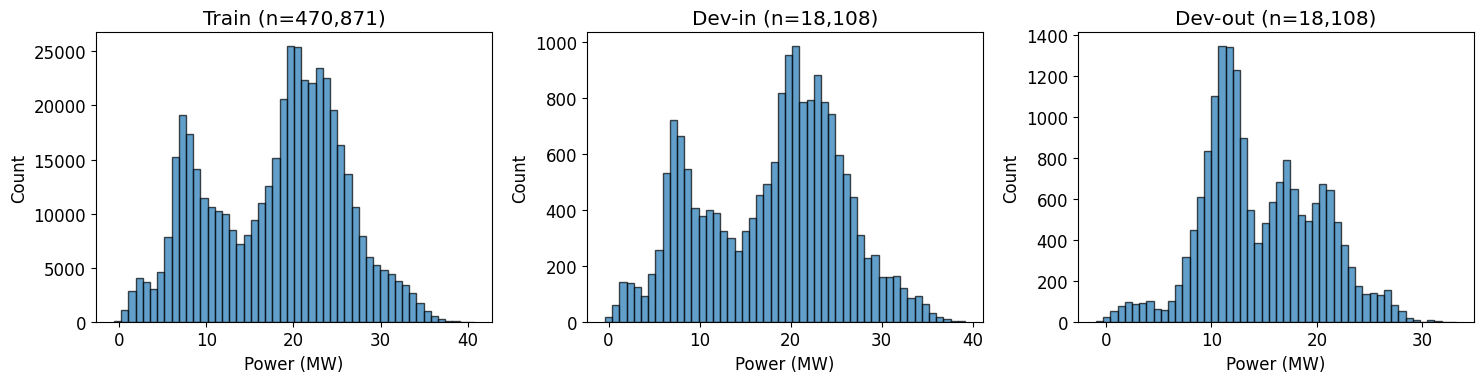

In [6]:
# Visualize target distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Dev-in', dev_in_df), ('Dev-out', dev_out_df)]):
    ax.hist(df['power'] / 1000, bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Power (MW)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} (n={len(df):,})')

plt.tight_layout()
plt.show()


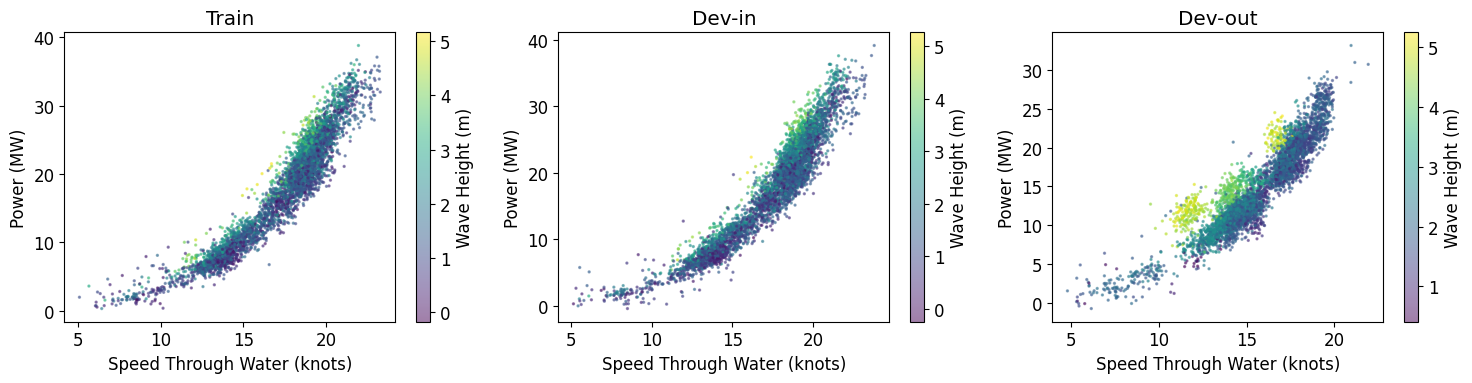

In [7]:
# Power vs Speed relationship
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Dev-in', dev_in_df), ('Dev-out', dev_out_df)]):
    sample = df.sample(min(5000, len(df)), random_state=42)
    scatter = ax.scatter(sample['stw'], sample['power'] / 1000, 
                         c=sample['comb_wind_swell_wave_height'], 
                         s=2, alpha=0.5, cmap='viridis')
    ax.set_xlabel('Speed Through Water (knots)')
    ax.set_ylabel('Power (MW)')
    ax.set_title(f'{name}')
    plt.colorbar(scatter, ax=ax, label='Wave Height (m)')

plt.tight_layout()
plt.show()


## 3. Feature Engineering

The data module automatically applies feature engineering. Let's see what features were created.


In [8]:
# Show engineered features
base_features = config.data.base_features
engineered_features = [f for f in data_module.feature_columns if f not in base_features]

print("Base features:")
for f in base_features:
    print(f"  - {f}")

print("\nEngineered features:")
for f in engineered_features:
    print(f"  - {f}")


Base features:
  - draft_aft_telegram
  - draft_fore_telegram
  - stw
  - diff_speed_overground
  - awind_vcomp_provider
  - awind_ucomp_provider
  - rcurrent_vcomp
  - rcurrent_ucomp
  - comb_wind_swell_wave_height
  - timeSinceDryDock

Engineered features:
  - stw_cubed
  - stw_squared
  - mean_draft
  - trim
  - wind_magnitude
  - wind_angle
  - current_magnitude
  - current_angle
  - speed_wind_interaction


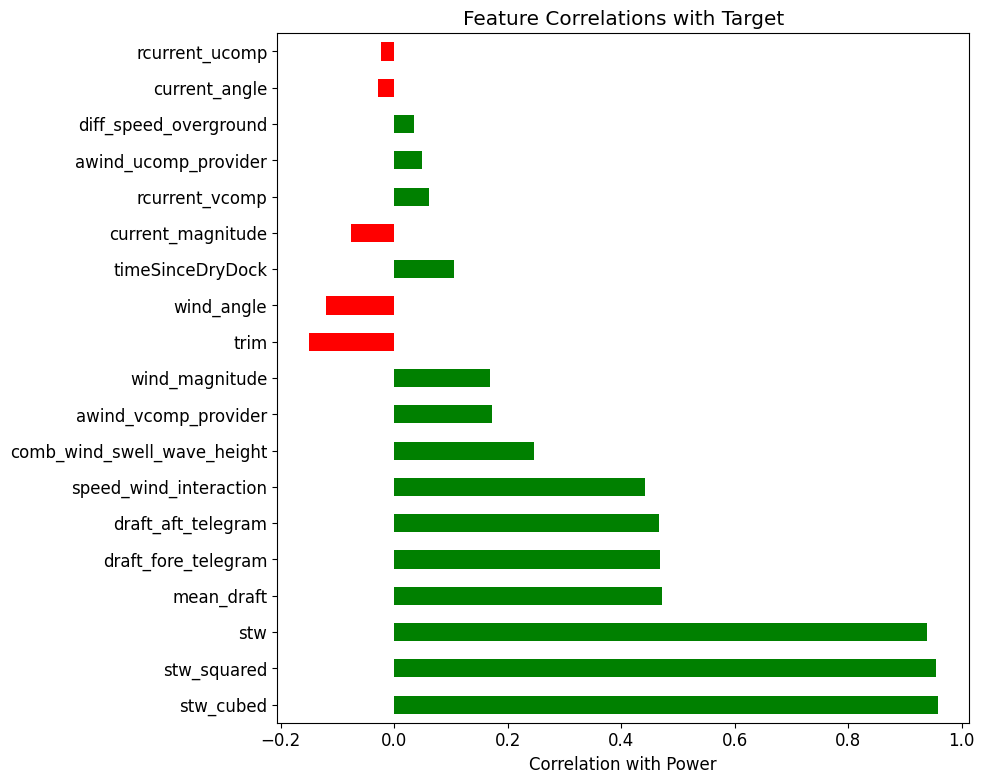

In [9]:
# Correlation with target
correlations = train_df[data_module.feature_columns + ['power']].corr()['power'].drop('power').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
correlations.plot(kind='barh', color=['green' if x > 0 else 'red' for x in correlations])
plt.xlabel('Correlation with Power')
plt.title('Feature Correlations with Target')
plt.tight_layout()
plt.show()


## 4. Baseline Models

Let's train and evaluate baseline models to establish performance benchmarks.


In [10]:
# Get scaled data
X_train, y_train = data_module.get_train_data()
X_val, y_val = data_module.get_val_data()
X_dev_in, y_dev_in = data_module.get_dev_in_data()
X_dev_out, y_dev_out = data_module.get_dev_out_data()

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")


Training data shape: (470871, 19)
Validation data shape: (52319, 19)


In [11]:
# Helper function to evaluate a model
def evaluate_model(model, name, X_train, y_train, data_module):
    """Train and evaluate a model on all splits."""
    
    # Train
    model.fit(X_train, y_train)
    
    results = {}
    
    for split_name, (X, y) in [('val', (X_val, y_val)), 
                                ('dev_in', (X_dev_in, y_dev_in)), 
                                ('dev_out', (X_dev_out, y_dev_out))]:
        y_pred = model.predict(X)
        
        # Scaled metrics
        mae_scaled = np.mean(np.abs(y_pred - y))
        rmse_scaled = np.sqrt(np.mean((y_pred - y) ** 2))
        
        # Original scale (kW)
        y_pred_kw = data_module.inverse_transform_predictions(y_pred)
        y_true_kw = data_module.inverse_transform_predictions(y)
        mae_kw = np.mean(np.abs(y_pred_kw - y_true_kw))
        
        results[split_name] = {
            'mae_scaled': mae_scaled,
            'rmse_scaled': rmse_scaled,
            'mae_kw': mae_kw
        }
    
    return results


In [12]:
# Train baseline models
baseline_results = {}

# Mean baseline
print("Training Mean Baseline...")
mean_model = create_baseline_model('mean', config.model)
baseline_results['Mean'] = evaluate_model(mean_model, 'Mean', X_train, y_train, data_module)

# Linear regression
print("Training Linear Regression...")
linear_model = create_baseline_model('linear', config.model)
baseline_results['Linear'] = evaluate_model(linear_model, 'Linear', X_train, y_train, data_module)

# Random Forest
print("Training Random Forest...")
rf_model = create_baseline_model('rf', config.model)
baseline_results['Random Forest'] = evaluate_model(rf_model, 'RF', X_train, y_train, data_module)

# XGBoost (if available)
try:
    print("Training XGBoost...")
    xgb_model = create_baseline_model('xgboost', config.model)
    xgb_model.fit(X_train, y_train, X_val, y_val)  # With early stopping
    
    # Evaluate manually since we already fitted
    xgb_results = {}
    for split_name, (X, y) in [('val', (X_val, y_val)), 
                                ('dev_in', (X_dev_in, y_dev_in)), 
                                ('dev_out', (X_dev_out, y_dev_out))]:
        y_pred = xgb_model.predict(X)
        y_pred_kw = data_module.inverse_transform_predictions(y_pred)
        y_true_kw = data_module.inverse_transform_predictions(y)
        xgb_results[split_name] = {
            'mae_scaled': np.mean(np.abs(y_pred - y)),
            'rmse_scaled': np.sqrt(np.mean((y_pred - y) ** 2)),
            'mae_kw': np.mean(np.abs(y_pred_kw - y_true_kw))
        }
    baseline_results['XGBoost'] = xgb_results
except ImportError:
    print("XGBoost not available, skipping...")

print("\nDone!")


Training Mean Baseline...
Training Linear Regression...
Training Random Forest...
Training XGBoost...

Done!


In [13]:
# Display baseline results
print("\nBaseline Model Results (MAE in kW):")
print("="*60)
print(f"{'Model':<20} {'Validation':<15} {'Dev-in':<15} {'Dev-out':<15}")
print("-"*60)

for name, results in baseline_results.items():
    val = results['val']['mae_kw']
    dev_in = results['dev_in']['mae_kw']
    dev_out = results['dev_out']['mae_kw']
    print(f"{name:<20} {val:<15.2f} {dev_in:<15.2f} {dev_out:<15.2f}")



Baseline Model Results (MAE in kW):
Model                Validation      Dev-in          Dev-out        
------------------------------------------------------------
Mean                 6462.12         6449.32         5343.92        
Linear               1002.31         1013.55         1100.29        
Random Forest        654.63          662.07          1044.52        
XGBoost              742.25          752.51          900.85         


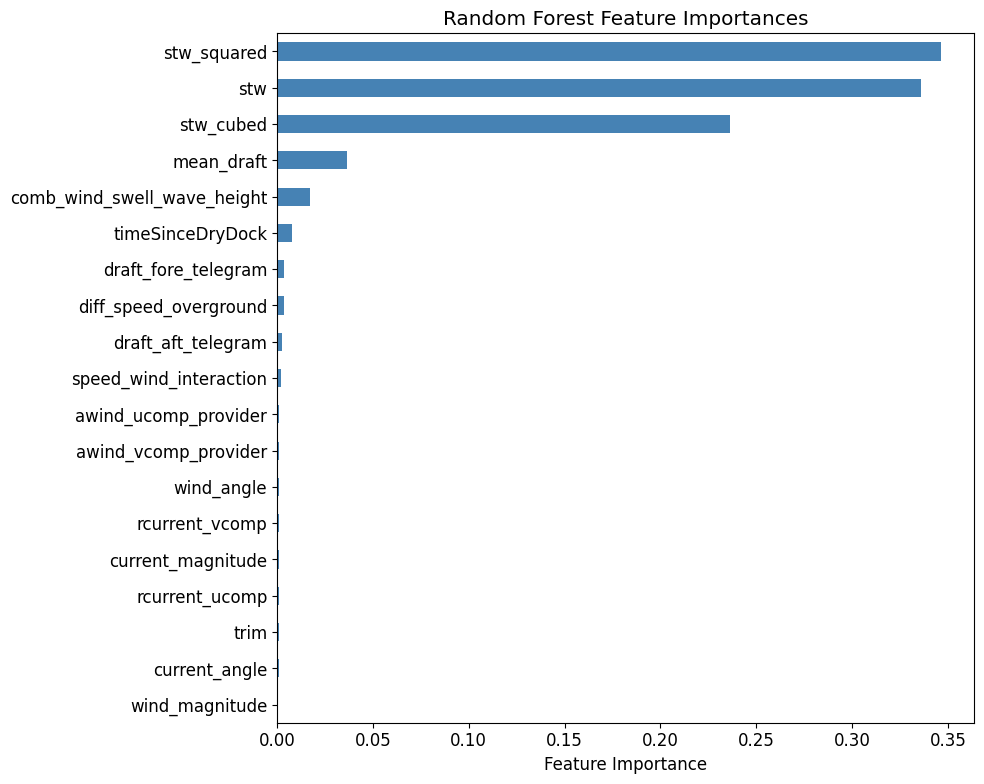

In [14]:
# Feature importance from Random Forest
if hasattr(rf_model, 'feature_importances_'):
    importance = pd.Series(rf_model.feature_importances_, index=data_module.feature_columns)
    importance = importance.sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    importance.plot(kind='barh', color='steelblue')
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.show()


## 5. Neural Network Models


In [15]:
# Train MLP
print("Training MLP...")
print(f"Architecture: {config.model.hidden_layers}")
print(f"Dropout: {config.model.dropout_rate}")

torch.manual_seed(SEED)
mlp_model = create_mlp(
    input_dim=data_module.n_features,
    config=config.model,
    gaussian_output=False
)

mlp_trainer = NeuralNetworkTrainer(
    model=mlp_model,
    learning_rate=config.model.learning_rate,
    batch_size=config.model.batch_size,
    max_epochs=config.model.max_epochs,
    early_stopping_patience=config.model.early_stopping_patience
)

mlp_history = mlp_trainer.train(X_train, y_train, X_val, y_val, verbose=True)


Training MLP...
Architecture: [128, 64, 32]
Dropout: 0.2
Epoch 10/100 - Train Loss: 0.039008, Val Loss: 0.020622
Epoch 20/100 - Train Loss: 0.038558, Val Loss: 0.018268
Epoch 30/100 - Train Loss: 0.038258, Val Loss: 0.018495
Epoch 40/100 - Train Loss: 0.037668, Val Loss: 0.018223
Early stopping at epoch 45


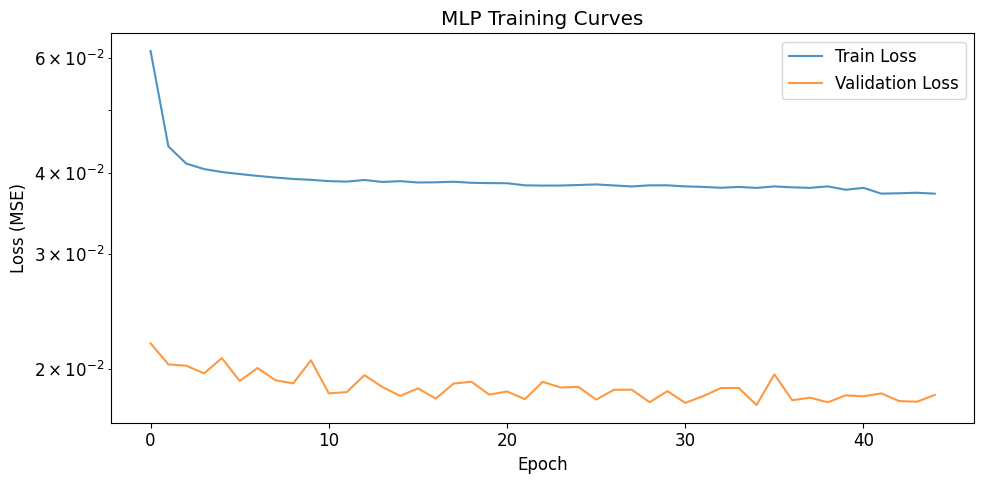

Best validation loss: 0.017609
Epochs trained: 45


In [16]:
# Plot training curves
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(mlp_history['train_losses'], label='Train Loss', alpha=0.8)
ax.plot(mlp_history['val_losses'], label='Validation Loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('MLP Training Curves')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"Best validation loss: {mlp_history['best_val_loss']:.6f}")
print(f"Epochs trained: {mlp_history['epochs_trained']}")


In [18]:
# Evaluate MLP
mlp_results = {}

for split_name, (X, y) in [('val', (X_val, y_val)), 
                            ('dev_in', (X_dev_in, y_dev_in)), 
                            ('dev_out', (X_dev_out, y_dev_out))]:
    y_pred = mlp_trainer.predict(X)
    
    y_pred_kw = data_module.inverse_transform_predictions(y_pred)
    y_true_kw = data_module.inverse_transform_predictions(y)
    
    mlp_results[split_name] = {
        'mae_scaled': np.mean(np.abs(y_pred - y)),
        'mae_kw': np.mean(np.abs(y_pred_kw - y_true_kw)),
        'rmse_kw': np.sqrt(np.mean((y_pred_kw - y_true_kw) ** 2))
    }
    print(f"{split_name}: MAE = {mlp_results[split_name]['mae_kw']:.2f} kW")


val: MAE = 781.30 kW
dev_in: MAE = 790.89 kW
dev_out: MAE = 921.30 kW


## 6. Uncertainty Quantification

We'll use a Deep Ensemble for robust uncertainty estimates.


In [19]:
# Train Deep Ensemble
print(f"Training Deep Ensemble with {config.model.n_ensemble_members} members...")

ensemble = DeepEnsemble(
    input_dim=data_module.n_features,
    n_members=config.model.n_ensemble_members,
    config=config.model,
    gaussian_output=False
)

ensemble_histories = ensemble.train(X_train, y_train, X_val, y_val, verbose=True)


Training Deep Ensemble with 5 members...

--- Training ensemble member 1/5 (seed=42) ---
Epoch 10/100 - Train Loss: 0.039008, Val Loss: 0.020622
Epoch 20/100 - Train Loss: 0.038558, Val Loss: 0.018268
Epoch 30/100 - Train Loss: 0.038258, Val Loss: 0.018495
Epoch 40/100 - Train Loss: 0.037668, Val Loss: 0.018223
Early stopping at epoch 45

--- Training ensemble member 2/5 (seed=1042) ---
Epoch 10/100 - Train Loss: 0.038414, Val Loss: 0.018707
Epoch 20/100 - Train Loss: 0.037176, Val Loss: 0.017598
Epoch 30/100 - Train Loss: 0.036440, Val Loss: 0.018095
Early stopping at epoch 30

--- Training ensemble member 3/5 (seed=2042) ---
Epoch 10/100 - Train Loss: 0.038419, Val Loss: 0.019796
Epoch 20/100 - Train Loss: 0.037037, Val Loss: 0.017914
Epoch 30/100 - Train Loss: 0.036823, Val Loss: 0.018154
Epoch 40/100 - Train Loss: 0.036449, Val Loss: 0.018103
Early stopping at epoch 46

--- Training ensemble member 4/5 (seed=3042) ---
Epoch 10/100 - Train Loss: 0.038291, Val Loss: 0.021322
Epoch 20

In [20]:
# Evaluate ensemble with uncertainty
ensemble_results = {}

print("\nEnsemble Results:")
print("="*70)

for split_name, (X, y) in [('val', (X_val, y_val)), 
                            ('dev_in', (X_dev_in, y_dev_in)), 
                            ('dev_out', (X_dev_out, y_dev_out))]:
    y_pred, epistemic, _ = ensemble.predict_with_uncertainty(X)
    uncertainty = np.sqrt(epistemic)  # Convert variance to std
    
    y_pred_kw = data_module.inverse_transform_predictions(y_pred)
    y_true_kw = data_module.inverse_transform_predictions(y)
    
    mae_kw = np.mean(np.abs(y_pred_kw - y_true_kw))
    
    # Uncertainty metrics
    errors = np.abs(y_pred - y)
    unc_metrics = compute_uncertainty_metrics(errors, uncertainty)
    
    ensemble_results[split_name] = {
        'mae_kw': mae_kw,
        'mean_uncertainty': np.mean(uncertainty),
        'correlation': unc_metrics['spearman_correlation']
    }
    
    print(f"\n{split_name}:")
    print(f"  MAE: {mae_kw:.2f} kW")
    print(f"  Mean uncertainty (std): {np.mean(uncertainty):.4f}")
    print(f"  Error-uncertainty correlation: {unc_metrics['spearman_correlation']:.4f}")



Ensemble Results:

val:
  MAE: 767.52 kW
  Mean uncertainty (std): 0.0186
  Error-uncertainty correlation: 0.0944

dev_in:
  MAE: 775.42 kW
  Mean uncertainty (std): 0.0187
  Error-uncertainty correlation: 0.0954

dev_out:
  MAE: 906.60 kW
  Mean uncertainty (std): 0.0341
  Error-uncertainty correlation: 0.0881


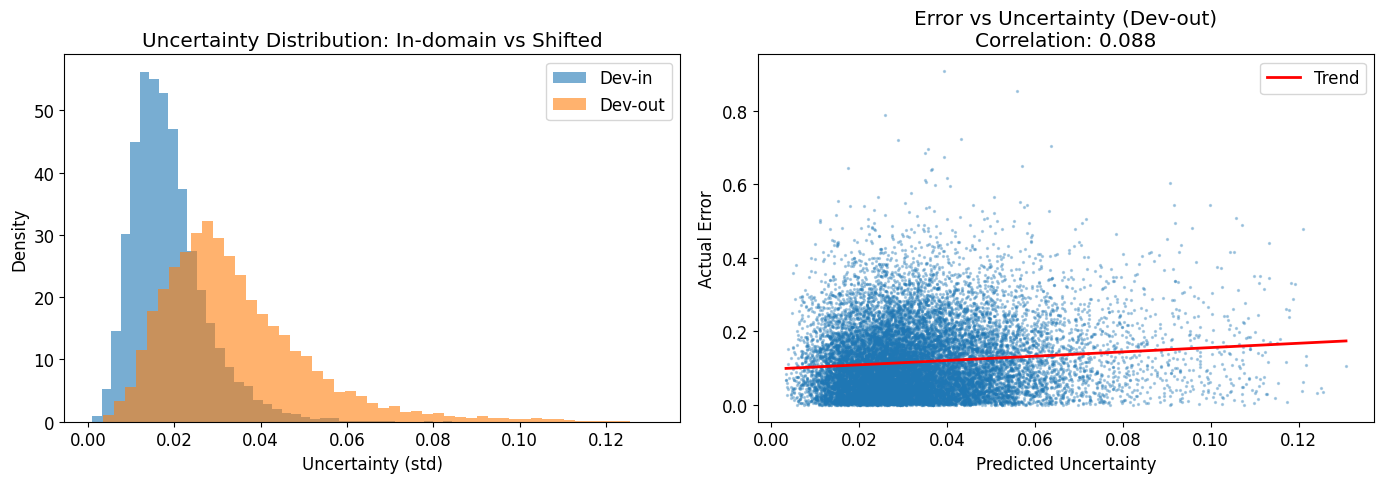

In [21]:
# Visualize uncertainty on dev_out (shifted data)
y_pred_out, epistemic_out, _ = ensemble.predict_with_uncertainty(X_dev_out)
uncertainty_out = np.sqrt(epistemic_out)

y_pred_in, epistemic_in, _ = ensemble.predict_with_uncertainty(X_dev_in)
uncertainty_in = np.sqrt(epistemic_in)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uncertainty distribution comparison
ax = axes[0]
ax.hist(uncertainty_in, bins=50, alpha=0.6, label='Dev-in', density=True)
ax.hist(uncertainty_out, bins=50, alpha=0.6, label='Dev-out', density=True)
ax.set_xlabel('Uncertainty (std)')
ax.set_ylabel('Density')
ax.set_title('Uncertainty Distribution: In-domain vs Shifted')
ax.legend()

# Error vs Uncertainty scatter
ax = axes[1]
errors_out = np.abs(y_pred_out - y_dev_out)
ax.scatter(uncertainty_out, errors_out, s=2, alpha=0.3)
ax.set_xlabel('Predicted Uncertainty')
ax.set_ylabel('Actual Error')
ax.set_title(f'Error vs Uncertainty (Dev-out)\nCorrelation: {ensemble_results["dev_out"]["correlation"]:.3f}')

# Add trend line
z = np.polyfit(uncertainty_out, errors_out, 1)
p = np.poly1d(z)
x_line = np.linspace(uncertainty_out.min(), uncertainty_out.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
ax.legend()

plt.tight_layout()
plt.show()


## 7. Model Comparison


In [22]:
# Compile all results
all_results = {
    'Mean Baseline': baseline_results.get('Mean', {}),
    'Linear': baseline_results.get('Linear', {}),
    'Random Forest': baseline_results.get('Random Forest', {}),
    'XGBoost': baseline_results.get('XGBoost', {}),
    'MLP': mlp_results,
    'Ensemble': {k: {'mae_kw': v['mae_kw']} for k, v in ensemble_results.items()}
}

# Remove empty entries
all_results = {k: v for k, v in all_results.items() if v}

# Create comparison dataframe
comparison_data = []
for model_name, results in all_results.items():
    row = {'Model': model_name}
    for split in ['val', 'dev_in', 'dev_out']:
        if split in results:
            row[f'{split}_mae'] = results[split]['mae_kw']
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
comparison_df['shift_gap'] = comparison_df['dev_out_mae'] - comparison_df['dev_in_mae']
comparison_df['shift_gap_pct'] = (comparison_df['shift_gap'] / comparison_df['dev_in_mae']) * 100

print("\nModel Comparison (MAE in kW):")
print(comparison_df.to_string(index=False))



Model Comparison (MAE in kW):
        Model     val_mae  dev_in_mae  dev_out_mae    shift_gap  shift_gap_pct
Mean Baseline 6462.123837 6449.317663  5343.924591 -1105.393072     -17.139690
       Linear 1002.314293 1013.550288  1100.294396    86.744108       8.558441
Random Forest  654.629789  662.068744  1044.515119   382.446375      57.765357
      XGBoost  742.246279  752.508068   900.854434   148.346366      19.713591
          MLP  781.303725  790.885932   921.304612   130.418679      16.490201
     Ensemble  767.515891  775.421453   906.604293   131.182840      16.917618


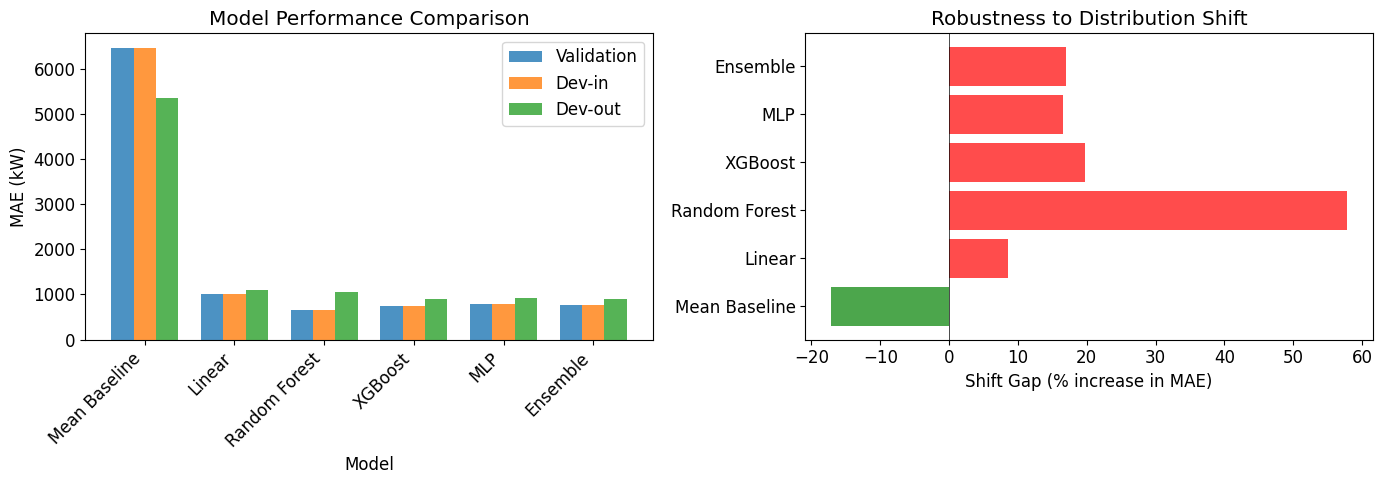

In [23]:
# Visualization of model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
ax = axes[0]
x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['val_mae'], width, label='Validation', alpha=0.8)
ax.bar(x, comparison_df['dev_in_mae'], width, label='Dev-in', alpha=0.8)
ax.bar(x + width, comparison_df['dev_out_mae'], width, label='Dev-out', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('MAE (kW)')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()

# Shift gap comparison
ax = axes[1]
colors = ['green' if x < 0 else 'red' for x in comparison_df['shift_gap']]
ax.barh(comparison_df['Model'], comparison_df['shift_gap_pct'], color=colors, alpha=0.7)
ax.set_xlabel('Shift Gap (% increase in MAE)')
ax.set_title('Robustness to Distribution Shift')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()


## 8. Distribution Shift Analysis


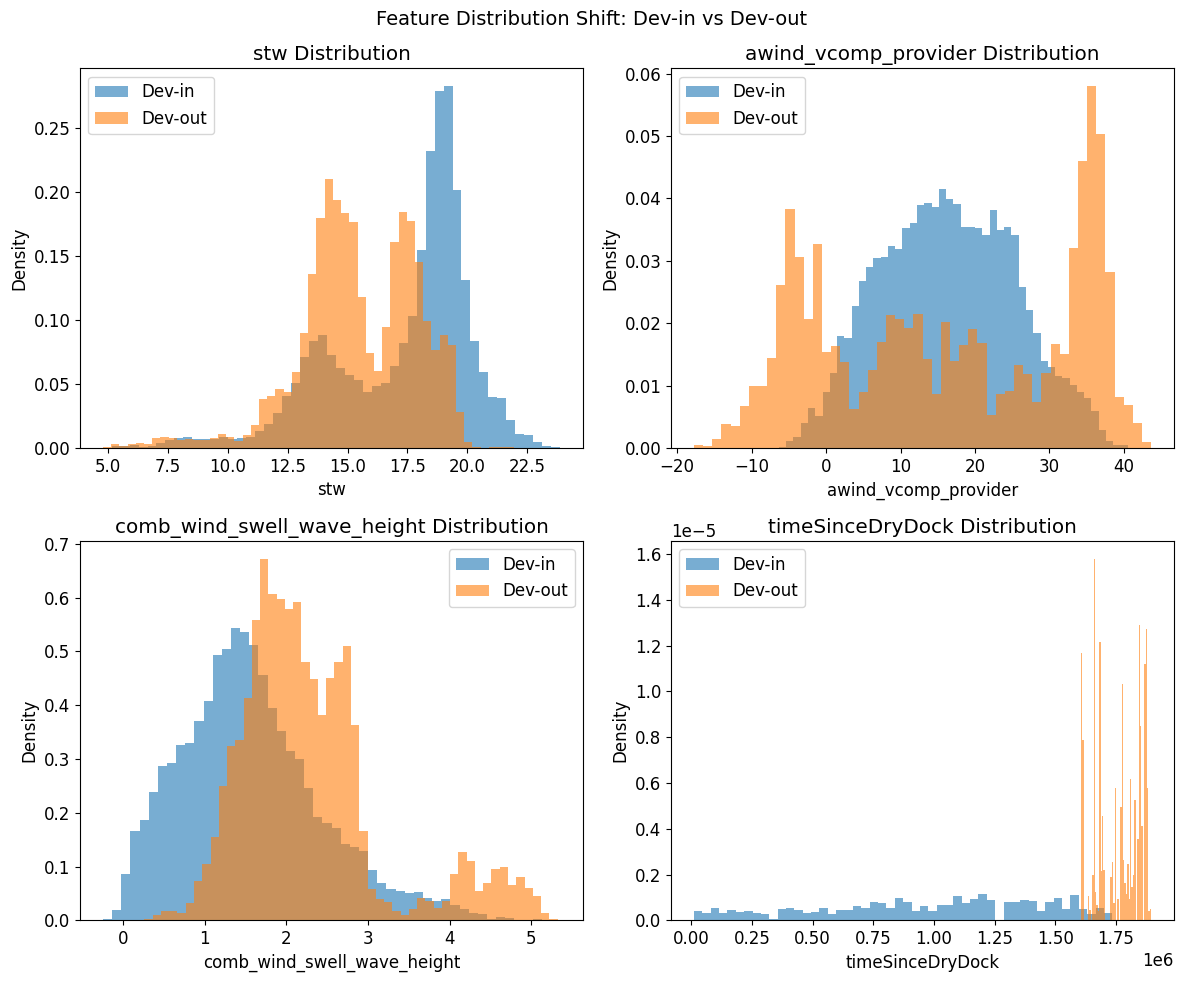

In [24]:
# Compare feature distributions between dev_in and dev_out
key_features = ['stw', 'awind_vcomp_provider', 'comb_wind_swell_wave_height', 'timeSinceDryDock']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, feature in zip(axes, key_features):
    if feature in dev_in_df.columns:
        ax.hist(dev_in_df[feature], bins=50, alpha=0.6, label='Dev-in', density=True)
        ax.hist(dev_out_df[feature], bins=50, alpha=0.6, label='Dev-out', density=True)
        ax.set_xlabel(feature)
        ax.set_ylabel('Density')
        ax.legend()
        ax.set_title(f'{feature} Distribution')

plt.suptitle('Feature Distribution Shift: Dev-in vs Dev-out', fontsize=14)
plt.tight_layout()
plt.show()


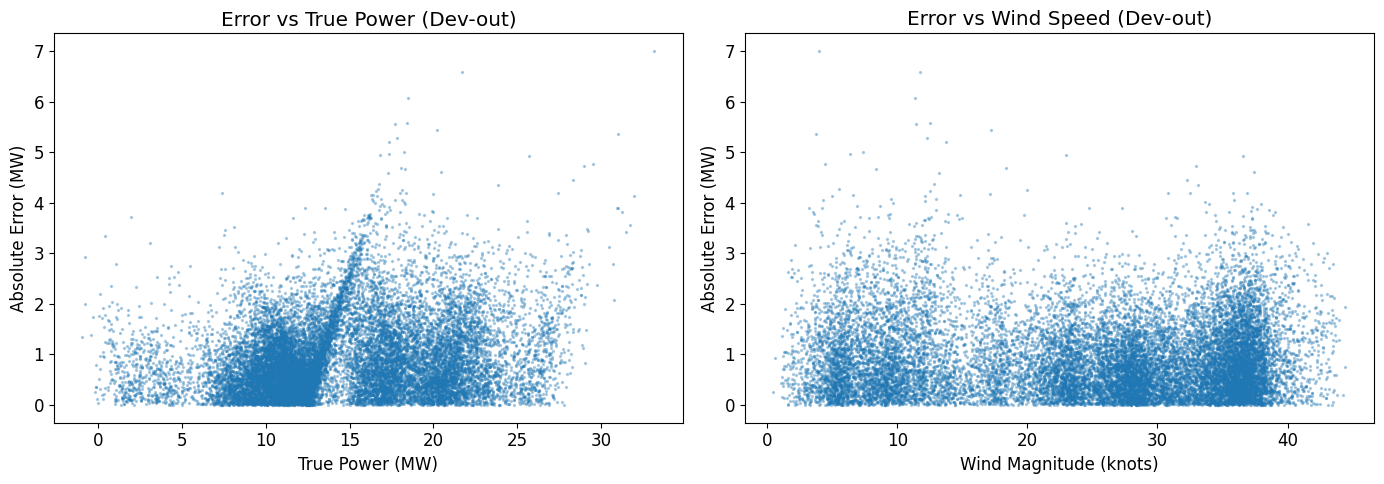

In [25]:
# Analyze where the model struggles most
y_pred_out_kw = data_module.inverse_transform_predictions(y_pred_out)
y_true_out_kw = data_module.get_raw_targets('dev_out')
errors_kw = np.abs(y_pred_out_kw - y_true_out_kw)

# Error vs actual power
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_true_out_kw / 1000, errors_kw / 1000, s=2, alpha=0.3)
ax.set_xlabel('True Power (MW)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Error vs True Power (Dev-out)')

# Error by wind speed
ax = axes[1]
wind_speed = dev_out_df['wind_magnitude'].values if 'wind_magnitude' in dev_out_df.columns else \
             np.sqrt(dev_out_df['awind_vcomp_provider']**2 + dev_out_df['awind_ucomp_provider']**2).values
ax.scatter(wind_speed, errors_kw / 1000, s=2, alpha=0.3)
ax.set_xlabel('Wind Magnitude (knots)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Error vs Wind Speed (Dev-out)')

plt.tight_layout()
plt.show()


## 9. Making Predictions on New Data

Here's how to use the trained models for inference.


In [26]:
def predict_power(model, data_module, features_dict):
    """
    Make a prediction for new input data.
    
    Args:
        model: Trained model or ensemble
        data_module: Data module with fitted scalers
        features_dict: Dictionary with feature values
        
    Returns:
        Predicted power in kW
    """
    # Create DataFrame with single row
    df = pd.DataFrame([features_dict])
    
    # Apply feature engineering
    df = data_module.feature_engineer.transform(df)
    
    # Get features in correct order
    X = df[data_module.feature_columns].values
    
    # Scale
    X_scaled = data_module.feature_scaler.transform(pd.DataFrame(X, columns=data_module.feature_columns))
    
    # Predict
    if isinstance(model, DeepEnsemble):
        y_scaled, uncertainty = model.get_total_uncertainty(X_scaled)
        y_kw = data_module.inverse_transform_predictions(y_scaled)
        return y_kw[0], np.sqrt(uncertainty[0]) * data_module.target_scaler.std
    else:
        y_scaled = model.predict(X_scaled)
        y_kw = data_module.inverse_transform_predictions(y_scaled)
        return y_kw[0], None


# Example prediction
example_input = {
    'draft_aft_telegram': 10.5,
    'draft_fore_telegram': 9.8,
    'stw': 15.0,  # Speed through water in knots
    'diff_speed_overground': 0.1,
    'awind_vcomp_provider': 10.0,
    'awind_ucomp_provider': 5.0,
    'rcurrent_vcomp': 0.5,
    'rcurrent_ucomp': 0.2,
    'comb_wind_swell_wave_height': 2.0,
    'timeSinceDryDock': 1000000  # minutes since dry dock
}

power_pred, uncertainty = predict_power(ensemble, data_module, example_input)

print("Example Prediction:")
print(f"  Input: STW={example_input['stw']} knots, Wave height={example_input['comb_wind_swell_wave_height']} m")
print(f"  Predicted Power: {power_pred/1000:.2f} MW")
if uncertainty:
    print(f"  Uncertainty (1 std): ±{uncertainty/1000:.2f} MW")


Example Prediction:
  Input: STW=15.0 knots, Wave height=2.0 m
  Predicted Power: 9.79 MW
  Uncertainty (1 std): ±0.07 MW


In [ ]:
# Save models for later use
print("Saving models...")

# Save scalers
data_module.save_scalers(config.checkpoint_dir)

# Save MLP
mlp_trainer.save(os.path.join(config.checkpoint_dir, 'mlp_model.pt'))

# Save ensemble
ensemble.save(os.path.join(config.checkpoint_dir, 'ensemble'))

# Save Random Forest
from models.baseline_models import save_model
save_model(rf_model, os.path.join(config.checkpoint_dir, 'rf_model.joblib'))
save_model(xgb_model, os.path.join(config.checkpoint_dir, 'xgb_model.joblib'))
print(f"XGBoost model saved to {config.checkpoint_dir}/xgb_model.joblib")

print(f"\nModels saved to {config.checkpoint_dir}")


Saving models...
Scalers saved to checkpoints
Model saved to checkpoints\mlp_model.pt
Model saved to checkpoints\ensemble\member_0.pt
Model saved to checkpoints\ensemble\member_1.pt
Model saved to checkpoints\ensemble\member_2.pt
Model saved to checkpoints\ensemble\member_3.pt
Model saved to checkpoints\ensemble\member_4.pt
Ensemble saved to checkpoints\ensemble
Model saved to checkpoints\rf_model.joblib

Models saved to checkpoints


## Summary

This notebook demonstrated:

1. **Data Loading**: Using `PropulsionDataModule` for clean, leak-free data handling
2. **Feature Engineering**: Automatic creation of derived features (speed cubed, wind magnitude, etc.)
3. **Baseline Models**: Mean, Linear, Random Forest, and XGBoost
4. **Neural Networks**: MLP with early stopping and learning rate scheduling
5. **Uncertainty Quantification**: Deep Ensembles for epistemic uncertainty
6. **Distribution Shift Analysis**: Comparing in-domain vs out-of-domain performance

### Key Takeaways

- Tree-based models (RF, XGBoost) provide strong baselines
- Neural networks can match or exceed tree models with proper tuning
- Deep Ensembles provide useful uncertainty estimates
- The dev_out set shows increased error due to distribution shift
- Uncertainty is generally higher for shifted data


In [28]:
# Final summary table
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("\nBest model (by Dev-out MAE):", comparison_df.loc[comparison_df['dev_out_mae'].idxmin(), 'Model'])
print("Most robust model (smallest shift gap):", comparison_df.loc[comparison_df['shift_gap'].abs().idxmin(), 'Model'])



FINAL RESULTS SUMMARY
        Model     val_mae  dev_in_mae  dev_out_mae    shift_gap  shift_gap_pct
Mean Baseline 6462.123837 6449.317663  5343.924591 -1105.393072     -17.139690
       Linear 1002.314293 1013.550288  1100.294396    86.744108       8.558441
Random Forest  654.629789  662.068744  1044.515119   382.446375      57.765357
      XGBoost  742.246279  752.508068   900.854434   148.346366      19.713591
          MLP  781.303725  790.885932   921.304612   130.418679      16.490201
     Ensemble  767.515891  775.421453   906.604293   131.182840      16.917618

Best model (by Dev-out MAE): XGBoost
Most robust model (smallest shift gap): Linear
